In [ ]:
import pandas as pd
import numpy as np

In [ ]:
eeg_df = pd.read_csv('/content/combined_file.csv')        # combined file with eeg features
behav_df = pd.read_csv('/content/reward_data_updated.csv')   # reward data

In [ ]:
merged_df = pd.concat([eeg_df, behav_df], axis=1)
merged_df["reward_diff"] = merged_df["reward"].diff().fillna(0)
decision_labels = (merged_df["reward_diff"].shift(-1) > 0).astype(int)
merged_df["decision"] = decision_labels

# Optional: first and last trial edge cases
merged_df.loc[merged_df.index[-1], "decision"] = 0  # last trial = stay (by default)

merged_df.to_csv("merged_eeg_behavior_labeled.csv", index=False)

In [ ]:
df = pd.read_csv('/content/merged_eeg_behavior_labeled.csv')

# Initialize new columns
df["patch_cumulative_reward"] = 0.0
df["patch_mean_reward"] = 0.0
df["patch_reward_slope"] = 0.0
df["trials_since_last_leave"] = 0

# Patch tracking variables
last_leave_index = -1

# Loop through each trial
for i in range(len(df)):
    # Get patch trials: from after last leave to current trial (inclusive)
    patch_trials = df.loc[last_leave_index + 1 : i]
    rewards = patch_trials["reward"].values
    trial_count = len(rewards)

    # Compute reward history features
    df.loc[i, "trials_since_last_leave"] = trial_count
    df.loc[i, "patch_cumulative_reward"] = np.sum(rewards)
    df.loc[i, "patch_mean_reward"] = np.mean(rewards)

    if trial_count > 1:
        x = np.arange(trial_count)
        slope = np.polyfit(x, rewards, 1)[0]
        df.loc[i, "patch_reward_slope"] = slope
    else:
        df.loc[i, "patch_reward_slope"] = 0.0

    # After assigning features, update patch boundary if it's a 'leave'
    if df.loc[i, "decision"] == 1:
        last_leave_index = i

# Save the final version
df.to_csv("final_eeg_behavior_with_reward_features.csv", index=False)
print("✅ Final patch-level reward features added and saved to 'final_eeg_behavior_with_reward_features.csv'")

✅ Final patch-level reward features added and saved to 'final_eeg_behavior_with_reward_features.csv'


In [ ]:
df = pd.read_csv('/content/final_eeg_behavior_with_reward_features.csv')

# Initialize beta trend features
df["patch_beta_mean"] = 0.0
df["patch_beta_slope"] = 0.0

# Tracking patch index
last_leave_index = -1

for i in range(len(df)):
    # Get patch range
    patch_df = df.loc[last_leave_index+1 : i]
    beta_vals = patch_df["beta_power_avg"].values

    # Beta mean
    df.loc[i, "patch_beta_mean"] = np.mean(beta_vals)

    # Beta slope
    if len(beta_vals) > 1:
        x = np.arange(len(beta_vals))
        slope = np.polyfit(x, beta_vals, 1)[0]
        df.loc[i, "patch_beta_slope"] = slope
    else:
        df.loc[i, "patch_beta_slope"] = 0.0

    # Update patch boundary
    if df.loc[i, "decision"] == 1:
        last_leave_index = i

# Select final feature set
feature_cols = [
    "beta_power_avg",             # current beta
    "patch_beta_mean",            # mean beta in patch
    "patch_beta_slope",           # trend in beta
    "aperiodic_exponent",         # E/I baseline
    "patch_cumulative_reward",
    "patch_mean_reward",
    "patch_reward_slope",
    "trials_since_last_leave"
]

X = df[feature_cols]
y = df["decision"]

print("✅ Feature matrix and labels ready:")
print(X.head())
print("\n🔖 Labels:")
print(y.value_counts())


✅ Feature matrix and labels ready:
   beta_power_avg  patch_beta_mean  patch_beta_slope  aperiodic_exponent  \
0    1.810000e-13     1.810000e-13      0.000000e+00            0.947939   
1    2.610000e-13     2.210000e-13      8.000000e-14            0.945706   
2    2.060000e-13     2.160000e-13      1.250000e-14            0.929326   
3    2.510000e-13     2.247500e-13      1.550000e-14            0.880384   
4    3.670000e-13     2.532000e-13      3.620000e-14            1.609602   

   patch_cumulative_reward  patch_mean_reward  patch_reward_slope  \
0                 6.862794           6.862794            0.000000   
1                13.178332           6.589166           -0.547256   
2                18.770953           6.256984           -0.635086   
3                23.745847           5.936462           -0.638662   
4                28.108156           5.621631           -0.634161   

   trials_since_last_leave  
0                        1  
1                        2  
2     

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Train logistic regression
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr.predict(X_test_scaled)

# Evaluate
print("📊 Logistic Regression Report:")
print(classification_report(y_test, y_pred_lr))

📊 Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92       158
           1       0.00      0.00      0.00        26

    accuracy                           0.86       184
   macro avg       0.43      0.50      0.46       184
weighted avg       0.74      0.86      0.79       184



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


📊 Random Forest Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       158
           1       0.50      0.04      0.07        26

    accuracy                           0.86       184
   macro avg       0.68      0.52      0.50       184
weighted avg       0.81      0.86      0.80       184



<ipython-input-10-686ee736132b>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_df, palette="viridis")
<ipython-input-10-686ee736132b>:27: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


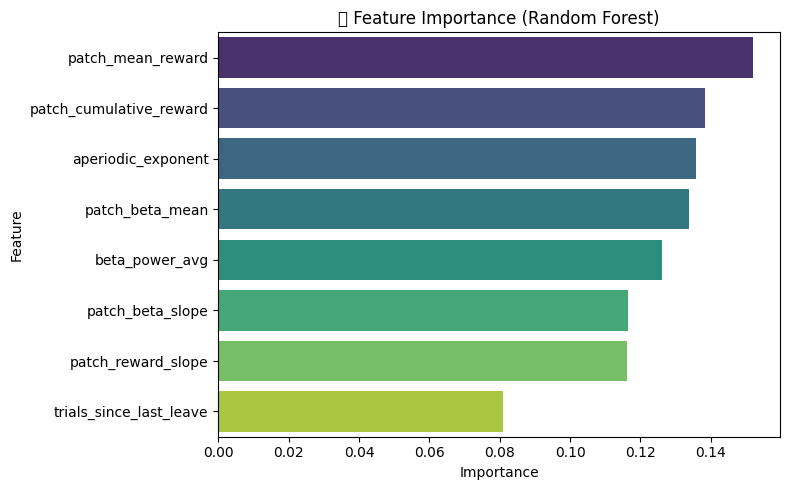

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
print("📊 Random Forest Report:")
print(classification_report(y_test, y_pred_rf))

# Feature Importance
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = rf.feature_importances_
feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x="Importance", y="Feature", data=feat_df, palette="viridis")
plt.title("🧠 Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()
